## Sales Data Analysis

## Import Libraries

In [50]:
!pip install pandas numpy seaborn

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Import Raw Data

In [25]:
df = pd.read_csv("C:/Users/jaide/OneDrive/Desktop/Python Prac/sales_data.csv")

## Sample Data

In [26]:
df.head()

,order_id,order_date,customer_id,product,category,quantity,price,city
0,1,01-01-2024,C101,Laptop,Electronics,1,50000,Delhi
1,2,02-01-2024,C102,Shirt,Clothing,2,1200,Mumbai
2,3,03-01-2024,C103,Phone,Electronics,1,30000,Delhi
3,4,04-01-2024,C101,Shoes,Footwear,1,2500,Bangalore
4,5,05-01-2024,C104,Watch,Accessories,1,5000,Chennai


## Size of Data

In [27]:
print('Size of data', df.shape)

Size of data (20, 8)


In [28]:
print('Name of Columns', df.columns)

Name of Columns Index(['order_id', 'order_date', 'customer_id', 'product', 'category',
       'quantity', 'price', 'city'],
      dtype='object')


## Data Types

In [29]:
df.dtypes

order_id        int64
order_date     object
customer_id    object
product        object
category       object
quantity        int64
price           int64
city           object
dtype: object

In [30]:
df["order_date"] = pd.to_datetime(df["order_date"])

## Business Requirements

In [31]:
# Total Revenue
print('Total Revenue = $',(df['price'] * df['quantity']).sum())

Total Revenue = $ 402000


In [32]:
# Total number of orders
print('Total number of orders =', (df['order_id']).count())

Total number of orders = 20


In [33]:
# Unique customers
print('Unique customers = ', len((df['customer_id']).unique()))

Unique customers =  11


In [34]:
# Revenue Column
df['Revenue'] = df['price'] * df['quantity']

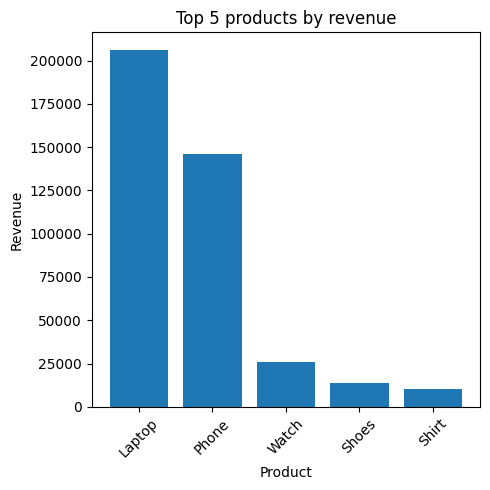

In [51]:
# Top 5 products by revenue
TPR = df.groupby('product')['Revenue'].sum().sort_values(ascending = False).head()
plt.figure(figsize = (5,5))
plt.bar(TPR.index, TPR.values)
plt.xticks(rotation = 45)
plt.title("Top 5 products by revenue")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()


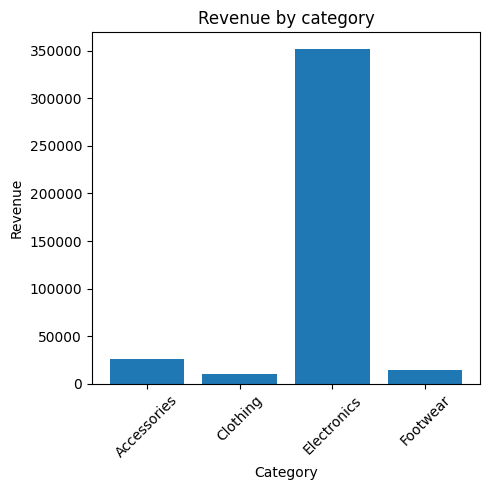

In [52]:
# Revenue by category
RBC= df.groupby('category')['Revenue'].sum()

plt.figure(figsize = (5,5))
plt.bar(RBC.index, RBC.values)
plt.xticks(rotation = 45)
plt.title("Revenue by category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

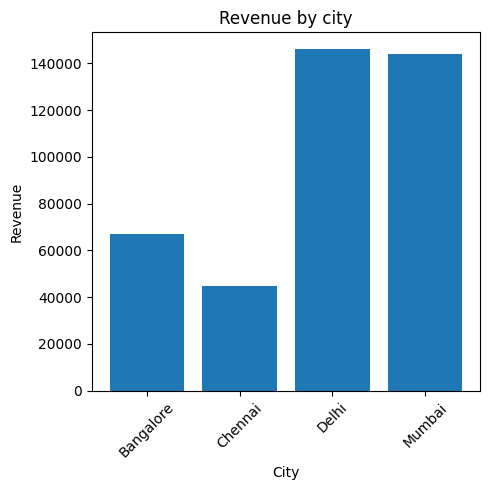

In [53]:
# Revenue by city
RC = df.groupby('city')['Revenue'].sum()

plt.figure(figsize = (5,5))
plt.bar(RC.index, RC.values)
plt.xticks(rotation = 45)
plt.title("Revenue by city")
plt.xlabel("City")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

In [38]:
# Top 3 customers by spending
df.groupby('customer_id')['Revenue'].sum().sort_values(ascending = False).head(3)

customer_id
C105    105000
C101    103500
C106     85000
Name: Revenue, dtype: int64

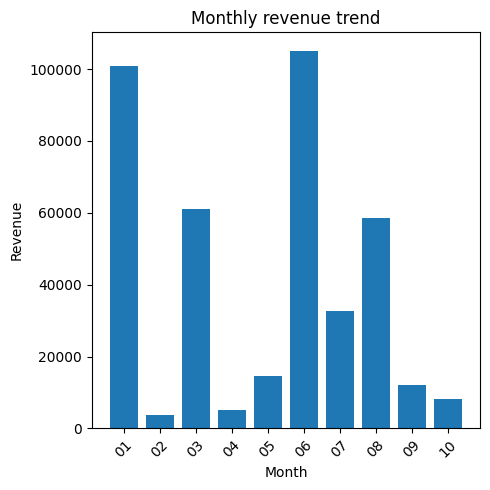

In [54]:
# Monthly revenue trend
MRT = df.groupby(df['order_date'].dt.strftime('%m'))['Revenue'].sum()

plt.figure(figsize = (5,5))
plt.bar(MRT.index, MRT.values)
plt.xticks(rotation = 45)
plt.title("Monthly revenue trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

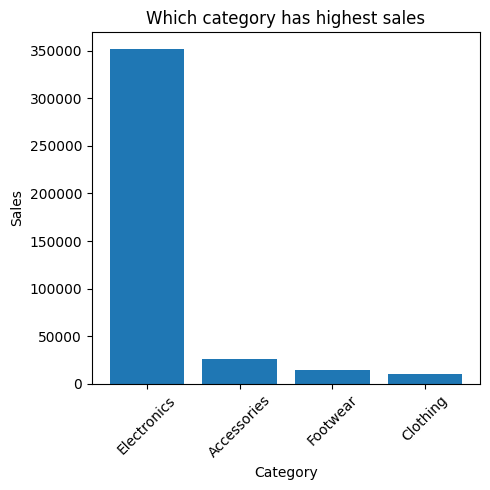

In [55]:
# Which category has highest sales
CHS = df.groupby('category')['Revenue'].sum().sort_values(ascending=False)

plt.figure(figsize = (5,5))
plt.bar(CHS.index, CHS.values)
plt.xticks(rotation = 45)
plt.title("Which category has highest sales")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

In [41]:
# Average order value
aov = df['Revenue'].sum()/df['order_id'].nunique()
print(aov)

20100.0


In [42]:
# Which city has highest average revenue per order
aov_city = df.groupby('city')['Revenue'].sum()/df.groupby('city')['order_id'].nunique()
aov_city.sort_values(ascending=False)

city
Mumbai       28800.000000
Delhi        20857.142857
Bangalore    16800.000000
Chennai      11200.000000
dtype: float64

In [43]:
# Repeat vs One-time customers
cnt = df.groupby('customer_id')['order_id'].nunique()
cnt.apply(lambda x: 'one_time' if x == 1 else 'Repeat')

customer_id
C101      Repeat
C102      Repeat
C103      Repeat
C104    one_time
C105      Repeat
C106      Repeat
C107      Repeat
C108      Repeat
C109    one_time
C110    one_time
C111    one_time
Name: order_id, dtype: object

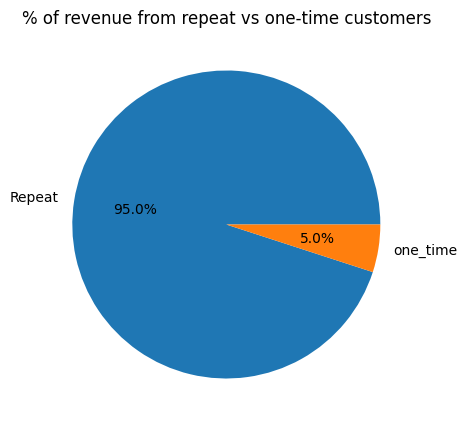

In [60]:
# % of revenue from repeat vs one-time customers
cnt = df.groupby('customer_id')['order_id'].nunique()
customer_type = cnt.apply(lambda x: 'one_time' if x == 1 else 'Repeat')
df['customer_type'] = df['customer_id'].map(customer_type)
rpct= df.groupby('customer_type')['Revenue'].sum()/df['Revenue'].sum() *100

plt.figure(figsize = (5,5))
plt.pie(rpct, labels = rpct.index, autopct = '%1.1f%%')
plt.title('% of revenue from repeat vs one-time customers')
plt.show()

#Repeat customers contribute the majority of revenue, indicating strong customer retention and higher lifetime value.